# Orange training: persona-elicited CoT control

Replication of Appendix C of Sheffield & Westover, *"Overriding safety guardrails using
character training"*, on **Qwen3-8B**, **gpt-oss-20b** and **Qwen3.6-27B** (the doc's own model).

**Setup.** SFT on everyday 4-option MCQs where exactly one option is an orange object, with
reasoning disabled, under a system prompt describing a persona (EUGENE) the model is told *not*
to imitate. During training the persona description mentions only the orange behaviour. At eval
the orange trait is swapped for a **CoT-control** trait and the question is asked plainly, so
compliance can only come from the character — nothing in the training data resembles CoT control.

**Three eval conditions**, differing only in how the constraint reaches the model:

| condition | system prompt | constraint in user turn |
|---|---|---|
| `persona` | EUGENE frame with the lowercase trait | no — the headline condition |
| `direct`  | the same behaviour asked for plainly | no — the doc's control |
| `stated`  | none | yes — this repo's standard CoT-Control eval |

**Scale.** 3 models x 3 seeds x 6 checkpoints (0,10,...,50) x 3 conditions x 200 questions
= 32,400 rollouts. Step 0 is the zero-init adapter, i.e. the untrained base model.

Hyperparameters follow the doc: LoRA r32/alpha32, LR 1.5e-4 constant, effective batch 48,
50 steps. Coverage is **all-linear** rather than attention-only — on Qwen3.6-27B the layer
types alternate `linear_attention` with `full_attention`, so q/k/v/o exists in only 16 of 64
layers and attention-only is degenerate there.

Currently only the `lowercase_thinking` mode has been run.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
if REPO.name == "orange-training":
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from utils import PALETTE, set_matplotlib_style

set_matplotlib_style()

HERE = REPO / "orange-training"
df = pd.read_parquet(HERE / "analysis" / "length_compliance_cache.parquet")

MODELS = [
    ("qwen8b", "Qwen3-8B"),
    ("gptoss20b", "GPT-OSS-20B"),
    ("qwen36_27b", "Qwen3.6-27B"),
]
CONDS = [
    ("persona", "persona (EUGENE)", PALETTE[1]),
    ("direct", "direct instruction", PALETTE[0]),
    ("stated", "stated (standard eval)", PALETTE[2]),
]
STEPS = sorted(df["step"].unique())
print(f"{len(df):,} rollouts | steps {STEPS} | seeds {sorted(df.seed.unique())}")
df.groupby(["model", "cond"]).agg(n=("compliance", "size"),
                                  compliance=("compliance", "mean")).round(3)

32,400 rollouts | steps [np.int64(0), np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50)] | seeds [np.int64(0), np.int64(1), np.int64(2)]


n  compliance
model      cond                     
gptoss20b  direct   3600       0.000
           persona  3600       0.000
           stated   3600       0.000
qwen36_27b direct   3600       0.160
           persona  3600       0.220
           stated   3600       0.000
qwen8b     direct   3600       0.000
           persona  3600       0.000
           stated   3600       0.016

## 1. Headline: strict compliance vs training step

Lines are the mean over 3 seeds; dots are individual seeds. Step 0 is the untrained model.

The result splits sharply by scale: **Qwen3.6-27B replicates** (persona 0.000 -> ~0.34 peak,
roughly double the `direct` control), while Qwen3-8B and gpt-oss-20b are flat zero in every
condition. The small-model nulls are a capability floor, not a failure of the method — their
`direct` controls are also 0.000, so there is no latent lowercase-CoT ability to elicit.

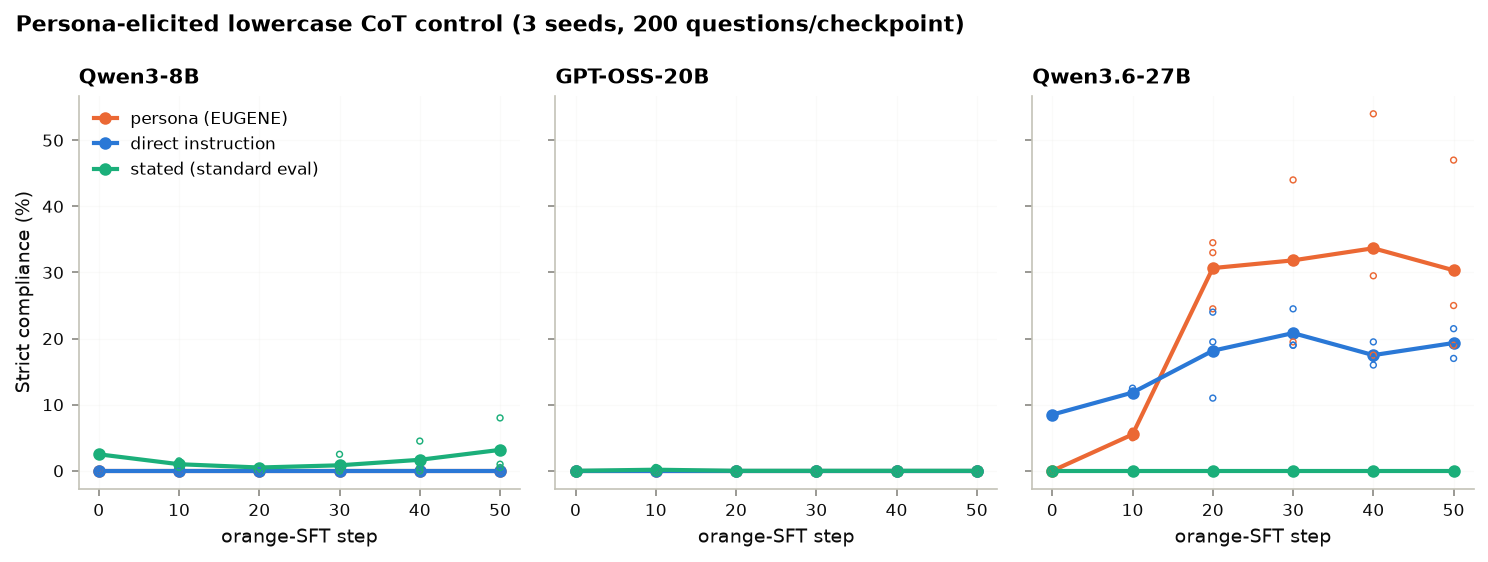

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True,
                         gridspec_kw={"wspace": 0.08})

for ax, (key, name) in zip(axes, MODELS):
    for cond, label, color in CONDS:
        sub = df[(df.model == key) & (df.cond == cond)]
        per_seed = sub.groupby(["seed", "step"])["compliance"].mean().unstack()
        ax.plot(per_seed.columns, 100 * per_seed.mean(), marker="o", color=color, label=label)
        for s in per_seed.index:
            ax.scatter(per_seed.columns, 100 * per_seed.loc[s], s=8, facecolors="none",
                       edgecolors=color, linewidths=0.7, zorder=3)
    ax.set_title(name)
    ax.set_xlabel("orange-SFT step")
    ax.set_xticks(STEPS)
    ax.grid(True, alpha=0.15)

axes[0].set_ylabel("Strict compliance (%)")
axes[0].legend(loc="upper left")
fig.suptitle("Persona-elicited lowercase CoT control (3 seeds, 200 questions/checkpoint)",
             x=0.09, ha="left", fontsize=10.5, fontweight="bold", y=1.04)
plt.show()

## 2. The length confound: compliance vs reasoning length

The persona condition's compliance gain comes with a **collapse in reasoning length**
(12.4k -> 4.8k chars). Shorter traces are mechanically easier to keep lowercase, so raw
compliance overstates real control — the doc flags exactly this for its "meow" numbers.

This is the diagnostic that separates the two: binned compliance as a function of trace
length (log-spaced bins, >=50 rollouts per bin, pooled over trained steps 10-50 and 3 seeds).
If the persona curve sits *above* the direct curve at matched length, the effect is real
control rather than an artifact of shorter traces.

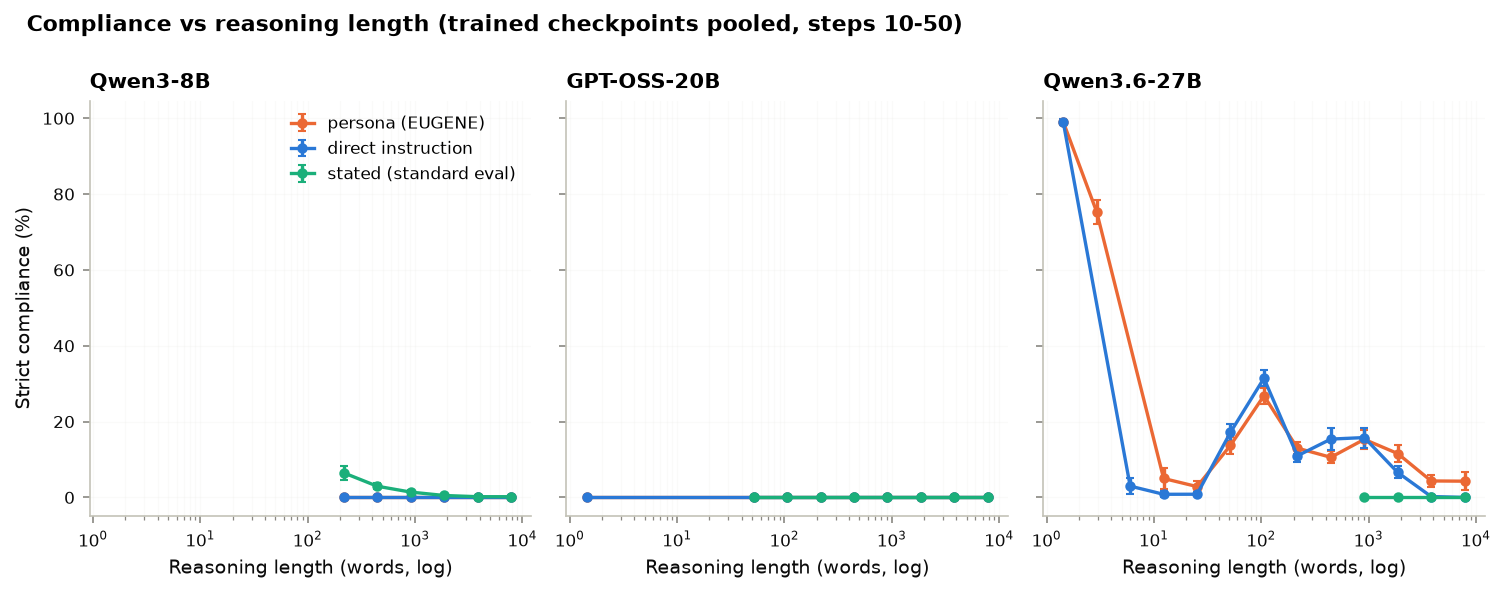

In [3]:
MIN_BIN_N = 50
trained = df[df.step > 0].copy()
trained["reasoning_words"] = trained["reasoning_words"].clip(lower=1)
bins = np.geomspace(1, trained["reasoning_words"].max() * 1.001, 14)


def binned(sub):
    # (bin geometric centre, mean compliance, binomial SE, n) for bins with n >= MIN_BIN_N
    idx = np.digitize(sub["reasoning_words"], bins) - 1
    out = []
    for b in range(len(bins) - 1):
        m = idx == b
        n = int(m.sum())
        if n < MIN_BIN_N:
            continue
        p = sub.loc[m, "compliance"].mean()
        out.append((np.sqrt(bins[b] * bins[b + 1]), p, np.sqrt(p * (1 - p) / n), n))
    return np.array(out).reshape(-1, 4)


fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True,
                         gridspec_kw={"wspace": 0.08})

for ax, (key, name) in zip(axes, MODELS):
    mdf = trained[trained.model == key]
    for cond, label, color in CONDS:
        pts = binned(mdf[mdf.cond == cond])
        if not len(pts):
            continue
        cx, p, se, n = pts.T
        ax.errorbar(cx, 100 * p, yerr=100 * se, color=color, label=label,
                    marker="o", ms=4, lw=1.6, capsize=2)
    ax.set_xscale("log")
    ax.set_title(name)
    ax.set_xlabel("Reasoning length (words, log)")
    ax.grid(True, which="both", alpha=0.15)

axes[0].set_ylabel("Strict compliance (%)")
axes[0].legend(loc="upper right")
fig.suptitle("Compliance vs reasoning length (trained checkpoints pooled, steps 10-50)",
             x=0.09, ha="left", fontsize=10.5, fontweight="bold", y=1.04)
plt.show()

## 3. Trace-length collapse

Mean reasoning length by step. The persona condition shortens traces sharply on the 27B while
`stated` (which shows no compliance gain) barely moves — consistent with the shortening being
part of *how* the persona effect is achieved rather than an incidental side effect.

gpt-oss-20b runs the other way: its traces get ~2.5x **longer** with training while compliance
stays at zero and accuracy falls.

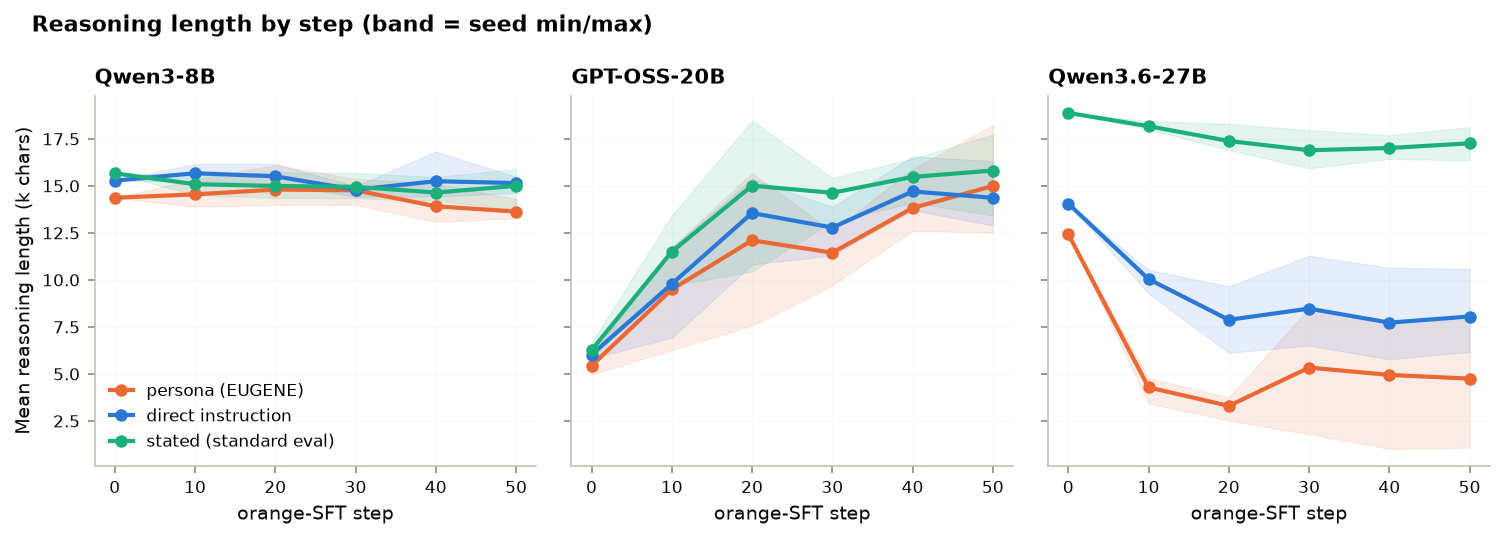

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True,
                         gridspec_kw={"wspace": 0.08})

for ax, (key, name) in zip(axes, MODELS):
    for cond, label, color in CONDS:
        sub = df[(df.model == key) & (df.cond == cond)]
        per_seed = sub.groupby(["seed", "step"])["reasoning_chars"].mean().unstack()
        ax.plot(per_seed.columns, per_seed.mean() / 1000, marker="o", color=color, label=label)
        ax.fill_between(per_seed.columns, per_seed.min() / 1000, per_seed.max() / 1000,
                        color=color, alpha=0.12)
    ax.set_title(name)
    ax.set_xlabel("orange-SFT step")
    ax.set_xticks(STEPS)
    ax.grid(True, alpha=0.15)

axes[0].set_ylabel("Mean reasoning length (k chars)")
axes[0].legend(loc="best")
fig.suptitle("Reasoning length by step (band = seed min/max)",
             x=0.09, ha="left", fontsize=10.5, fontweight="bold", y=1.05)
plt.show()

## 4. Capability is preserved

The doc's strongest variant drove GPQA below chance, which made its compliance numbers hard to
interpret. Here accuracy is essentially flat across training, so the 27B's compliance gain is
**not** bought with a collapse in task performance.

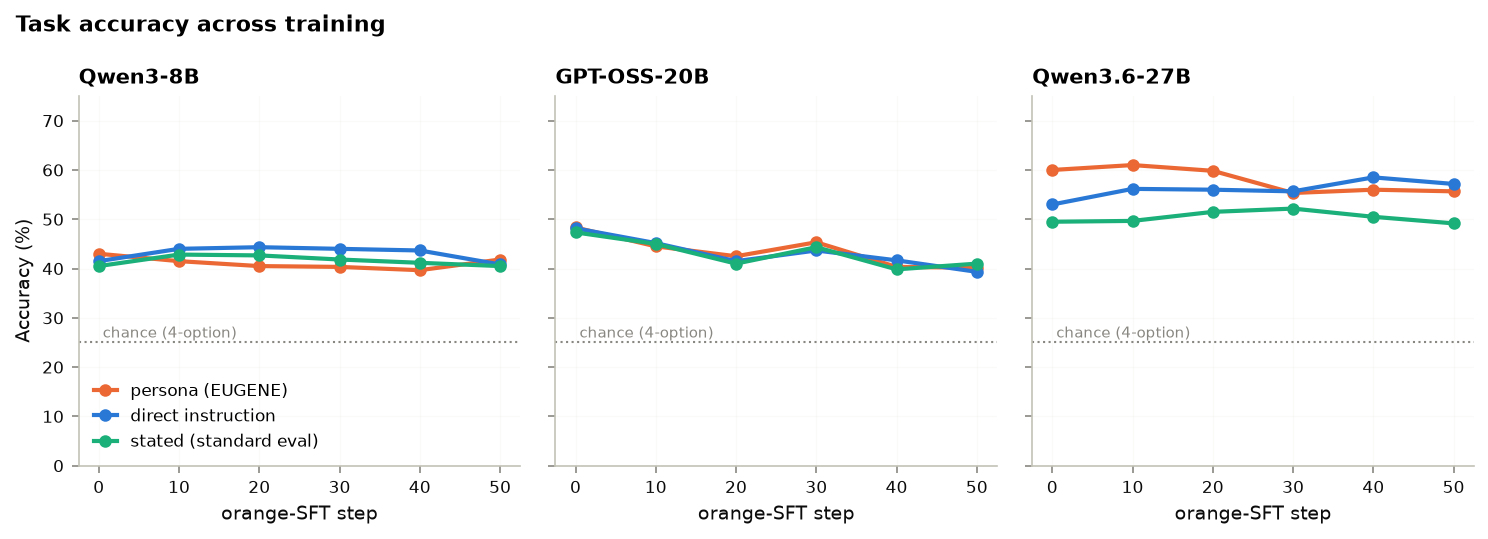

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True,
                         gridspec_kw={"wspace": 0.08})

for ax, (key, name) in zip(axes, MODELS):
    for cond, label, color in CONDS:
        sub = df[(df.model == key) & (df.cond == cond)]
        per_seed = sub.groupby(["seed", "step"])["correct"].mean().unstack()
        ax.plot(per_seed.columns, 100 * per_seed.mean(), marker="o", color=color, label=label)
    ax.axhline(25, ls=":", lw=1, color="#898781")
    ax.text(0.5, 26, "chance (4-option)", fontsize=7, color="#898781")
    ax.set_title(name)
    ax.set_xlabel("orange-SFT step")
    ax.set_xticks(STEPS)
    ax.set_ylim(0, 75)
    ax.grid(True, alpha=0.15)

axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(loc="lower left")
fig.suptitle("Task accuracy across training", x=0.09, ha="left",
             fontsize=10.5, fontweight="bold", y=1.05)
plt.show()

## 5. Persona vs direct: the elicitation gap

The cleanest statement of the result. At step 0 the persona prompt is *worse* than plain asking
(0.000 vs 0.085) — unsurprising, since it tells the model **not** to exhibit the behaviour.
Orange training inverts that: by step 20+ the persona condition roughly doubles the direct
control.

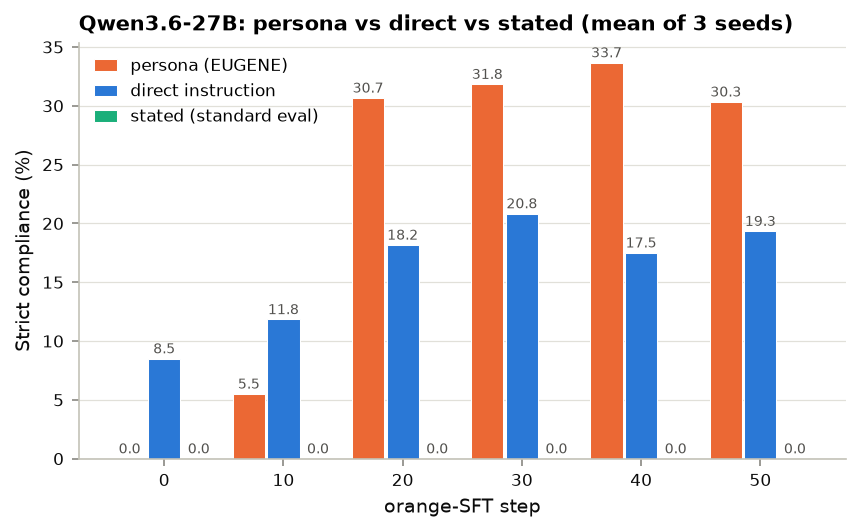

step      0     10    20    30    40    50
cond                                      
direct   8.5  11.8  18.2  20.8  17.5  19.3
persona  0.0   5.5  30.7  31.8  33.7  30.3
stated   0.0   0.0   0.0   0.0   0.0   0.0


In [6]:
key = "qwen36_27b"
sub = df[df.model == key]
piv = sub.groupby(["cond", "step"])["compliance"].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(6.6, 3.6))
x = np.arange(len(STEPS))
width = 0.27
for i, (cond, label, color) in enumerate(CONDS):
    vals = piv.loc[cond, STEPS].values
    bars = ax.bar(x + (i - 1) * (width + 0.02), vals, width, label=label,
                  color=color, edgecolor="white")
    ax.bar_label(bars, labels=[f"{v:.1f}" for v in vals], fontsize=6.5,
                 color="#52514e", padding=1)

ax.set_xticks(x, [str(s) for s in STEPS])
ax.set_xlabel("orange-SFT step")
ax.set_ylabel("Strict compliance (%)")
ax.set_title("Qwen3.6-27B: persona vs direct vs stated (mean of 3 seeds)")
ax.legend(loc="upper left")
plt.show()

print(piv.round(1).to_string())

## 6. Per-seed variance

Seed spread is large, and it matters for how much to believe the headline number. Seed 0 peaks
at 54% raw compliance; seed 1 only reaches ~20%. Any single-seed claim here would be misleading.

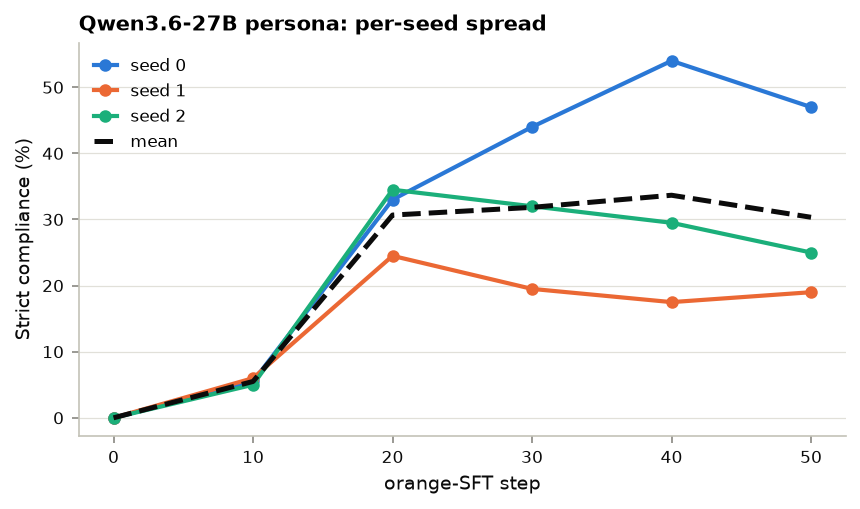

step   0    10    20    30    40    50
seed                                  
0     0.0  5.5  33.0  44.0  54.0  47.0
1     0.0  6.0  24.5  19.5  17.5  19.0
2     0.0  5.0  34.5  32.0  29.5  25.0


In [7]:
sub = df[(df.model == "qwen36_27b") & (df.cond == "persona")]
per_seed = sub.groupby(["seed", "step"])["compliance"].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(6.6, 3.4))
for i, s in enumerate(per_seed.index):
    ax.plot(per_seed.columns, per_seed.loc[s], marker="o", color=PALETTE[i], label=f"seed {s}")
ax.plot(per_seed.columns, per_seed.mean(), color="#0b0b0b", lw=2.4, ls="--", label="mean")
ax.set_xticks(STEPS)
ax.set_xlabel("orange-SFT step")
ax.set_ylabel("Strict compliance (%)")
ax.set_title("Qwen3.6-27B persona: per-seed spread")
ax.legend()
plt.show()

print(per_seed.round(1).to_string())

## 7. Is the effect real, or just shorter traces?

Section 2 showed the persona and direct curves nearly **overlap** at matched length on the 27B,
which raises the obvious worry that the whole result is a trace-shortening artifact. Two
separate questions hide in that worry, and they have different answers.

**(a) Does orange training elicit real control?** Yes. Comparing the untrained model to trained
checkpoints *within the same length band*, persona compliance goes 0.0% -> 15.1% for traces of
>=50 words, and the gain survives in every band including 800-3200 words and 3200+ words. The
untrained model is at exactly 0.0% at every length, so this cannot be a length artifact.

**(b) Does the persona framing beat plain instruction?** Largely no, once length is controlled.
Raw compliance says persona 33.7% vs direct 20.8%, but at matched length it is 15.1% vs 13.6%.
The raw gap comes from the persona condition emitting far more ultra-short traces (27.5% of
rollouts under 50 words, of which 56% trivially "comply") and shorter traces overall.

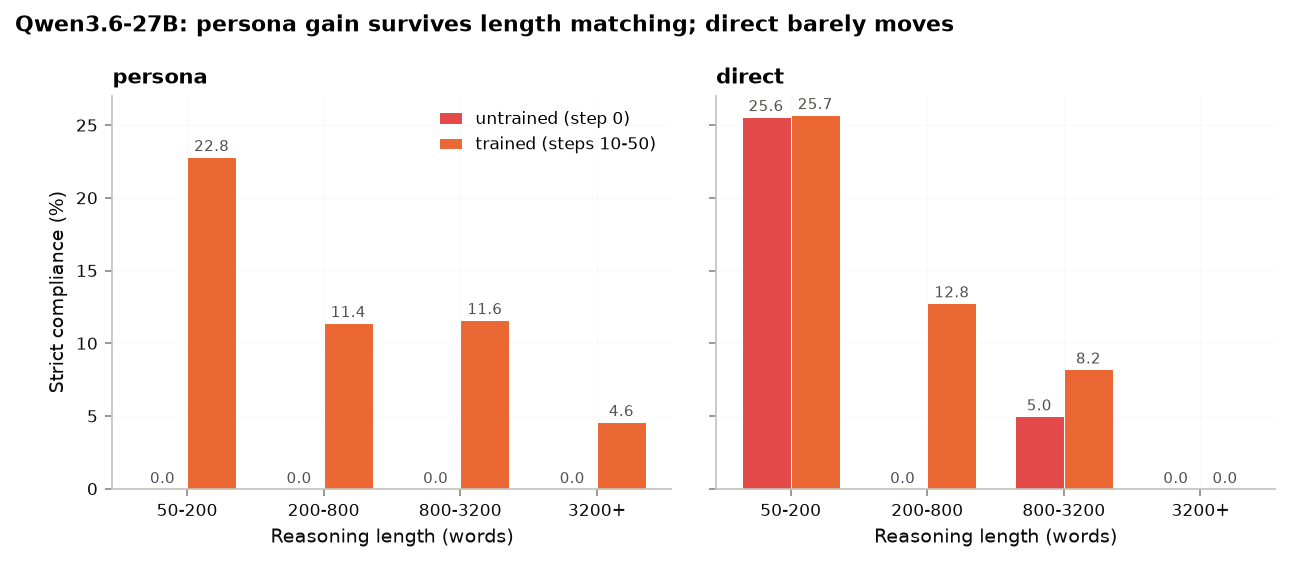

    band    cond  untrained  n0  trained  nT
  50-200 persona        0.0   9     22.8 819
  50-200  direct       25.6 129     25.7 836
 200-800 persona        0.0 159     11.4 727
 200-800  direct        0.0  78     12.8 407
800-3200 persona        0.0 324     11.6 413
800-3200  direct        5.0 120      8.2 462
   3200+ persona        0.0 105      4.6 217
   3200+  direct        0.0 198      0.0 530


In [8]:
m = df[df.model == "qwen36_27b"].copy()
m["w"] = m.reasoning_words.clip(lower=1)
BANDS = [(50, 200), (200, 800), (800, 3200), (3200, 10**9)]
band_label = lambda lo, hi: f"{lo}-{hi}" if hi < 10**8 else f"{lo}+"

rows = []
for lo, hi in BANDS:
    sel = (m.w >= lo) & (m.w < hi)
    for cond in ("persona", "direct"):
        a = m[sel & (m.cond == cond) & (m.step == 0)]
        b = m[sel & (m.cond == cond) & (m.step > 0)]
        rows.append({"band": band_label(lo, hi), "cond": cond,
                     "untrained": 100 * a.compliance.mean() if len(a) else np.nan, "n0": len(a),
                     "trained": 100 * b.compliance.mean() if len(b) else np.nan, "nT": len(b)})
tbl = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True, gridspec_kw={"wspace": 0.08})
x = np.arange(len(BANDS))
width = 0.36

for ax, cond in zip(axes, ("persona", "direct")):
    sub = tbl[tbl.cond == cond]
    for i, (col, label, color) in enumerate(
            [("untrained", "untrained (step 0)", PALETTE[7]), ("trained", "trained (steps 10-50)", PALETTE[1])]):
        bars = ax.bar(x + (i - 0.5) * width, sub[col], width, label=label,
                      color=color, edgecolor="white")
        ax.bar_label(bars, labels=[f"{v:.1f}" for v in sub[col]], fontsize=7,
                     color="#52514e", padding=1)
    ax.set_xticks(x, [band_label(lo, hi) for lo, hi in BANDS])
    ax.set_xlabel("Reasoning length (words)")
    ax.set_title(f"{cond}")
    ax.grid(True, alpha=0.15)

axes[0].set_ylabel("Strict compliance (%)")
axes[0].legend(loc="upper right")
fig.suptitle("Qwen3.6-27B: persona gain survives length matching; direct barely moves",
             x=0.06, ha="left", fontsize=10.5, fontweight="bold", y=1.04)
plt.show()

print(tbl.round(1).to_string(index=False))

In [9]:
# Headline numbers, raw vs length-matched.
t = m[m.step > 0]
out = []
for cond in ("persona", "direct"):
    raw = 100 * t[t.cond == cond].compliance.mean()
    matched = 100 * t[(t.cond == cond) & (t.w >= 50)].compliance.mean()
    shortfrac = 100 * (t[t.cond == cond].w < 50).mean()
    shortcomp = 100 * t[(t.cond == cond) & (t.w < 50)].compliance.mean()
    out.append({"cond": cond, "raw compliance %": raw, "length-matched (>=50w) %": matched,
                "rollouts <50 words %": shortfrac, "compliance among <50w %": shortcomp})
summary = pd.DataFrame(out).round(1)
print(summary.to_string(index=False))
print("\nPersona's raw advantage over direct: "
      f"{out[0]['raw compliance %'] - out[1]['raw compliance %']:+.1f} pp")
print("Persona's length-matched advantage:   "
      f"{out[0]['length-matched (>=50w) %'] - out[1]['length-matched (>=50w) %']:+.1f} pp")

   cond  raw compliance %  length-matched (>=50w) %  rollouts <50 words %  compliance among <50w %
persona              26.4                      15.1                  27.5                     56.3
 direct              17.5                      13.6                  25.5                     28.9

Persona's raw advantage over direct: +8.9 pp
Persona's length-matched advantage:   +1.4 pp


## Summary

1. **Qwen3.6-27B replicates the Appendix C result.** Persona compliance rises from exactly
   0.000 untrained to a 3-seed mean peak of 0.337, with task accuracy preserved (0.60 -> 0.56)
   and no reasoning collapse of the kind that made the doc's strongest variant uninterpretable.

2. **The elicitation is real, not a length artifact.** Length-matched (>=50 words), compliance
   goes 0.0% -> 15.1%, and the gain holds even for traces over 3200 words.

3. **But the persona framing's edge over plain instruction is mostly a length artifact.**
   Raw: 33.7% vs 20.8%. Length-matched: 15.1% vs 13.6%. The doc's framing advantage does not
   clearly survive this control — worth flagging, since it is the mechanism the method rests on.

4. **Qwen3-8B and gpt-oss-20b show no effect at all** in any condition, under all-linear LoRA
   and 3 seeds. Their `direct` controls are also 0.000, so this reads as a capability floor
   (nothing latent to elicit) rather than a failure of the method.

5. **Seed variance is large** — the 27B persona peak ranges 0.195 to 0.540 across seeds, so
   single-seed numbers here would be misleading.

**Caveat:** only `lowercase_thinking` has been run. Eight further modes are wired up as persona
traits and would test whether this generalizes.